# Week 5: Exploratory Data Analysis and Operational Diagnostics

## Operational Diagnostics Investigation

### Objective

The objective of this analysis is to investigate operational performance using the provided Mystery Operations dataset. Through exploratory data analysis (EDA), anomaly detection, and diagnostic techniques such as drill-down analysis, Pareto analysis, and correlation analysis, this notebook aims to identify the root causes of operational issues and recommend actionable improvements for the operations team.

The analysis follows a structured investigation process:
- Data profiling
- Exploratory data analysis
- Anomaly detection
- Root cause analysis
- Business recommendations

## 1. Import Required Libraries

The first step is to import the Python libraries that will be used throughout the analysis.

- **Pandas** for loading and manipulating the dataset.
- **NumPy** for numerical operations.
- **Matplotlib** and **Seaborn** for data visualization.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

The Mystery Operations dataset is loaded into a Pandas DataFrame so that it can be explored and analyzed.

In [2]:
# Load dataset
df = pd.read_csv("Mystery_Ops.csv")

# Display first five records
df.head()

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,15/10/2026,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,18/05/2026,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,09/02/2026,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,18/03/2026,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


## 3. Initial Exploration

Before analyzing the data, it is important to understand its structure, identify missing values, and check for duplicate records. This helps ensure the quality of subsequent analyses.

In [3]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2920, 11)

Columns:
['record_id', 'operation_date', 'depot', 'shift', 'operator_id', 'machine_id', 'throughput_barrels', 'temperature_c', 'maintenance_flag', 'voltage_count', 'incident_type']

Data Types:
record_id              object
operation_date         object
depot                  object
shift                  object
operator_id            object
machine_id             object
throughput_barrels    float64
temperature_c         float64
maintenance_flag        int64
voltage_count           int64
incident_type          object
dtype: object


In [4]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           2920 non-null   object 
 1   operation_date      2920 non-null   object 
 2   depot               2920 non-null   object 
 3   shift               2920 non-null   object 
 4   operator_id         2902 non-null   object 
 5   machine_id          2920 non-null   object 
 6   throughput_barrels  2915 non-null   float64
 7   temperature_c       2900 non-null   float64
 8   maintenance_flag    2920 non-null   int64  
 9   voltage_count       2920 non-null   int64  
 10  incident_type       2920 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 251.1+ KB


In [5]:
# Summary statistics
df.describe(include="all")

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
count,2920,2920,2920,2920,2902,2920,2915.000000,2900.000000,2920.000000,2920.000000,2920
unique,2920,365,4,2,15,13,NaN,NaN,NaN,NaN,4
top,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-E02,NBI-P03,NaN,NaN,NaN,NaN,none
freq,1,8,730,1460,253,566,NaN,NaN,NaN,NaN,2332
mean,NaN,NaN,NaN,NaN,NaN,NaN,916.891149,25.050310,0.186644,221.122945,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,168.122566,5.567664,0.389692,6.518187,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,296.500000,10.900000,0.000000,197.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,872.850000,21.200000,0.000000,217.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,969.300000,25.100000,0.000000,221.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1029.650000,29.100000,0.000000,225.000000,NaN


In [6]:
# Missing values
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
record_id,0,0.00
operation_date,0,0.00
depot,0,0.00
shift,0,0.00
operator_id,18,0.62
machine_id,0,0.00
throughput_barrels,5,0.17
temperature_c,20,0.68
maintenance_flag,0,0.00
voltage_count,0,0.00


In [7]:
# Duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


### Initial Findings

The dataset contains **2,920 operational records** across eleven variables describing production activities.

The initial assessment revealed a small number of missing values in the **operator_id**, **throughput_barrels**, and **temperature_c** columns. Since the proportion of missing data is very low, it is unlikely to significantly affect the analysis.

No duplicate records were identified, indicating that each operational record represents a unique observation.

## 4. Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution, identify unusual values, and summarize key characteristics. Numerical variables are visualized using histograms and box plots, while categorical variables are explored using frequency distributions and bar charts.

In [8]:
# Numerical columns
numerical_cols = [
    "throughput_barrels",
    "temperature_c",
    "voltage_count"
]

# Summary statistics
df[numerical_cols].describe()

,throughput_barrels,temperature_c,voltage_count
count,2915.000000,2900.000000,2920.000000
mean,916.891149,25.050310,221.122945
std,168.122566,5.567664,6.518187
min,296.500000,10.900000,197.000000
25%,872.850000,21.200000,217.000000
50%,969.300000,25.100000,221.000000
75%,1029.650000,29.100000,225.000000
max,1210.600000,39.900000,242.000000


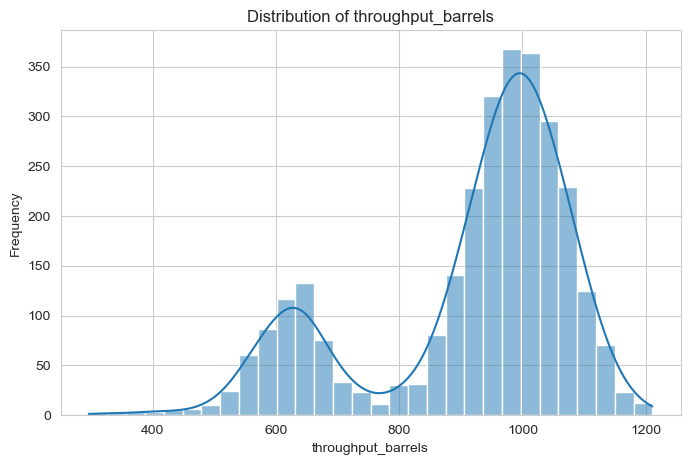

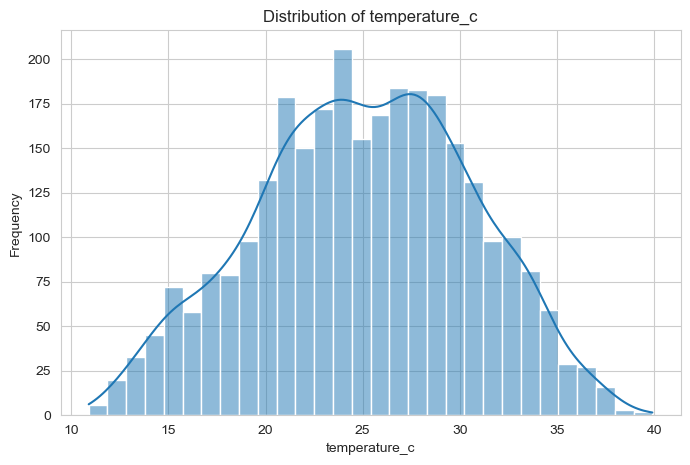

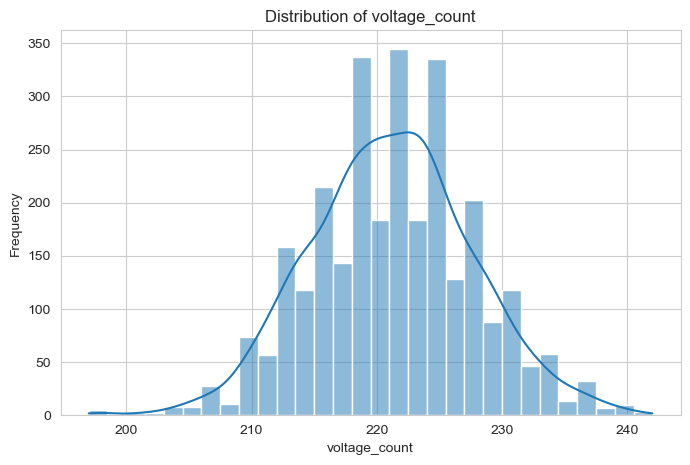

In [9]:
# Histograms for numerical variables

for column in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[column], bins=30, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

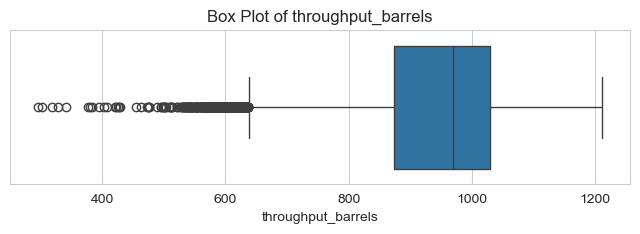

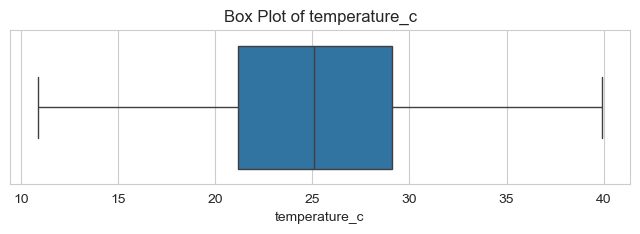

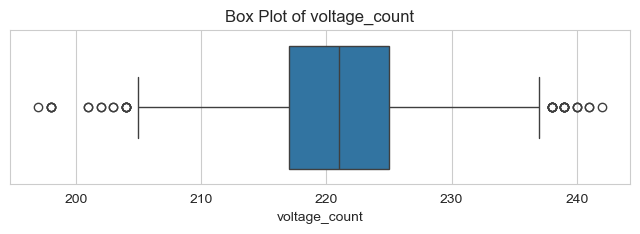

In [10]:
# Boxplots for numerical variables

for column in numerical_cols:
    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(f"Box Plot of {column}")

    plt.show()

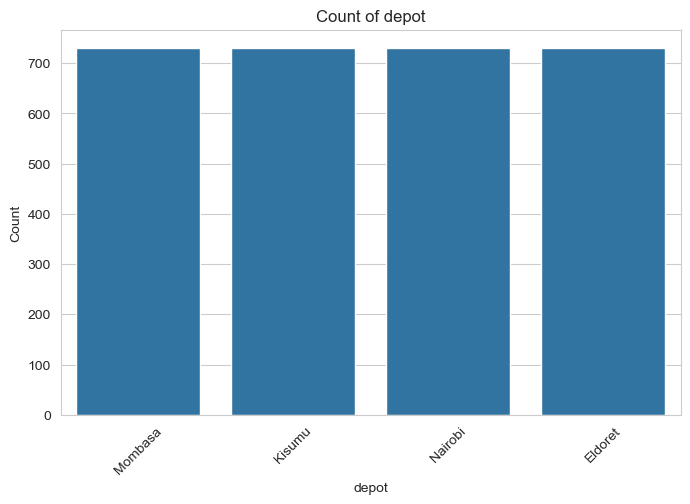

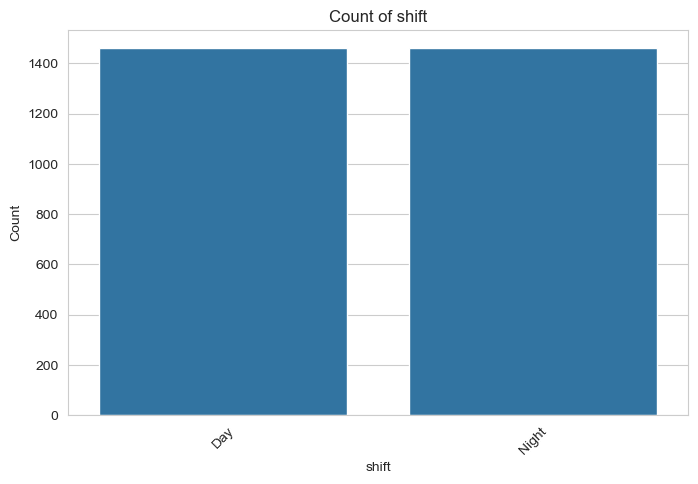

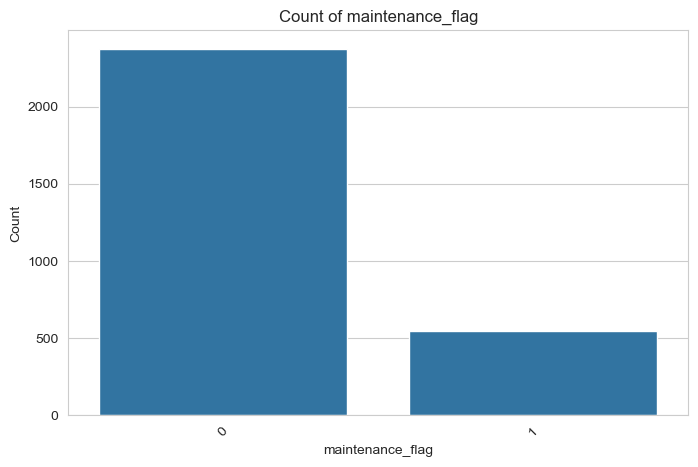

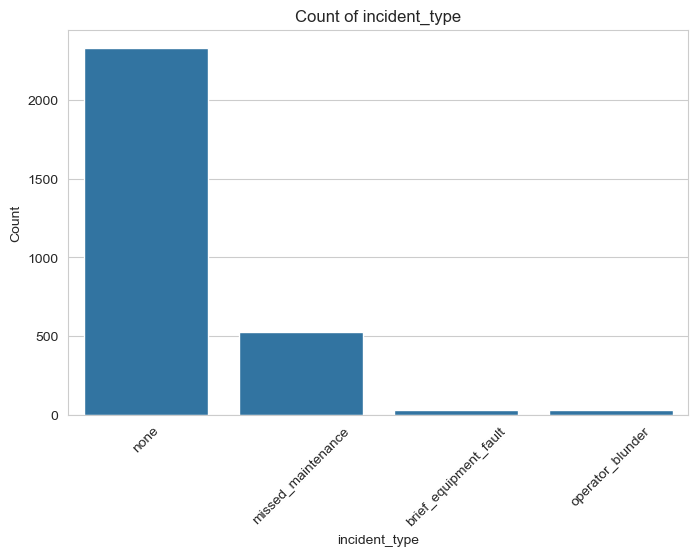

In [11]:
categorical_cols = [
    "depot",
    "shift",
    "maintenance_flag",
    "incident_type"
]

for column in categorical_cols:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Count of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

In [12]:
for column in categorical_cols:

    print(f"\nFrequency Distribution: {column}")

    print(df[column].value_counts())

    print("-"*40)


Frequency Distribution: depot
depot
Mombasa    730
Kisumu     730
Nairobi    730
Eldoret    730
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: shift
shift
Day      1460
Night    1460
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: maintenance_flag
maintenance_flag
0    2375
1     545
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: incident_type
incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64
----------------------------------------
